# ANALISIS EXPLORATORIO FINAL - RETO 06 LIBERE

### ANALISIS DF COMPLETO

In [15]:
#Cargar librerias
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colors import LinearSegmentedColormap

In [2]:
#Cargar datos
path = os.path.join('Datos', 'Limpios', 'df_final.csv')
df = pd.read_csv(path)

In [ ]:
#Columnas
df.columns

In [10]:
# Tipo de columnas:
print(df.dtypes)

lead_time                           int64
lenght_of_stay                      int64
checkin_month                      object
checkin_day                        object
adult_count                         int64
child_count                         int64
origin                             object
travel_agency_name                 object
requested_category                 object
requested_category_name            object
asset                              object
asset_type                         object
brand                              object
available_units                     int64
business_segment                   object
rate                               object
rate_group_name                    object
rate_type                          object
completed_entry_forms_count       float64
all_entry_forms_completed          object
returning_inhabitant               object
recurrence                          int64
libere_community                   object
bought_products                   

In [6]:
# Tamaño
df.shape

(53747, 44)

In [4]:
# Visualizar primeras 5 instancias
print(df.head(5))

   lead_time  lenght_of_stay checkin_month checkin_day  adult_count  \
0         36               1       January      Sunday            1   
1         11               9       January      Sunday            1   
2        102               6       January      Sunday            2   
3         99               1       January      Sunday            2   
4         75               1       January      Sunday            4   

   child_count           origin travel_agency_name requested_category  \
0            0  channel_manager        Booking.com         Hostel bed   
1            0  channel_manager        Booking.com         Hostel bed   
2            4  channel_manager        Booking.com        Hostel room   
3            2  channel_manager        Booking.com        Hostel room   
4            0  channel_manager        Booking.com        Hostel room   

                     requested_category_name  ... Estacion_Estancia  \
0  6 bed community room with shared bathroom  ...            Wi

In [80]:
#Crear paleta de colores
paleta =["#F48A48","#6F4E37","#EBB68D","#391704"]

GRAFICOS

1º GRAFICO: Mes de check-in vs duración media

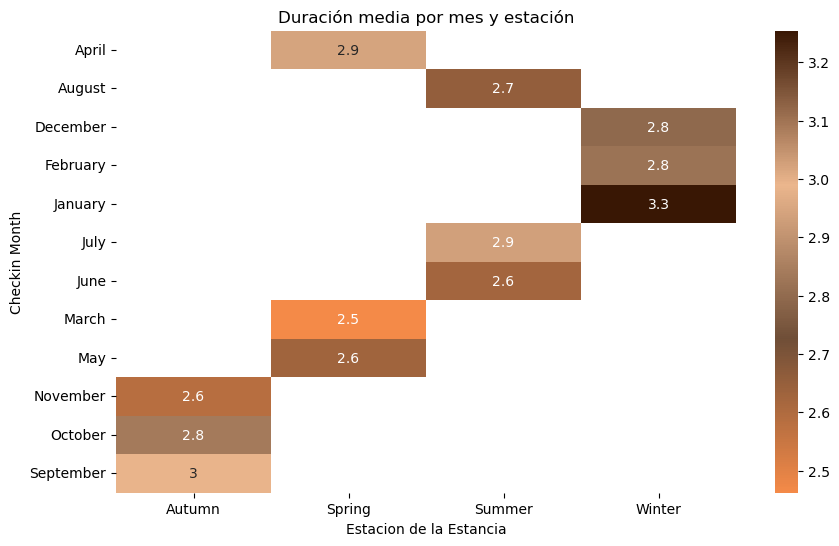

In [31]:
# Paleta personalizada:
mi_cmap = LinearSegmentedColormap.from_list(
    "mi_paleta",
    list(paleta))

pivot = df.pivot_table(
    values='lenght_of_stay',
    index='checkin_month',
    columns='Estacion_Estancia',
    aggfunc='mean')

#Grafico
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap=mi_cmap)
plt.title("Duración media por mes y estación")
plt.ylabel("Checkin Month")
plt.xlabel("Estacion de la Estancia")
plt.show()


2º GRAFICO: Distribución del Lead Time (reserva anticipada)

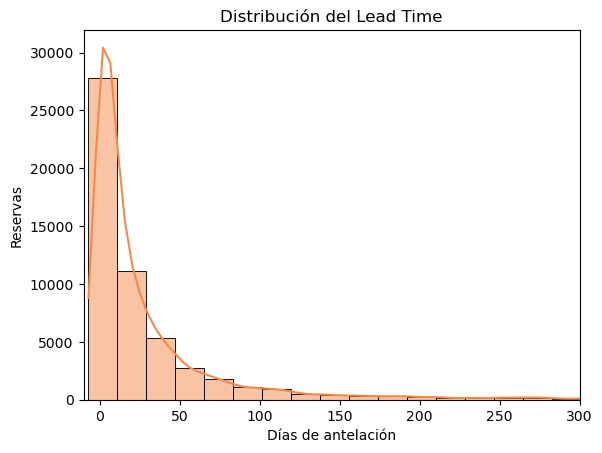

In [38]:
sns.histplot(df["lead_time"], bins=50, kde=True, color = paleta[0])
plt.title("Distribución del Lead Time")
plt.xlabel("Días de antelación")
plt.ylabel("Reservas")
plt.xlim(-10,300)
plt.show()

3º GRAFICO: Distribución del Lead Time según rango de recurrencia

C:\Users\Larau\AppData\Local\Temp\ipykernel_65924\406197897.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby('recurrence_range')['lead_time'].mean().reset_index()
C:\Users\Larau\AppData\Local\Temp\ipykernel_65924\406197897.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Larau\AppData\Local\Temp\ipykernel_65924\406197897.py:16: UserWarning: 
The palette list has fewer values (4) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


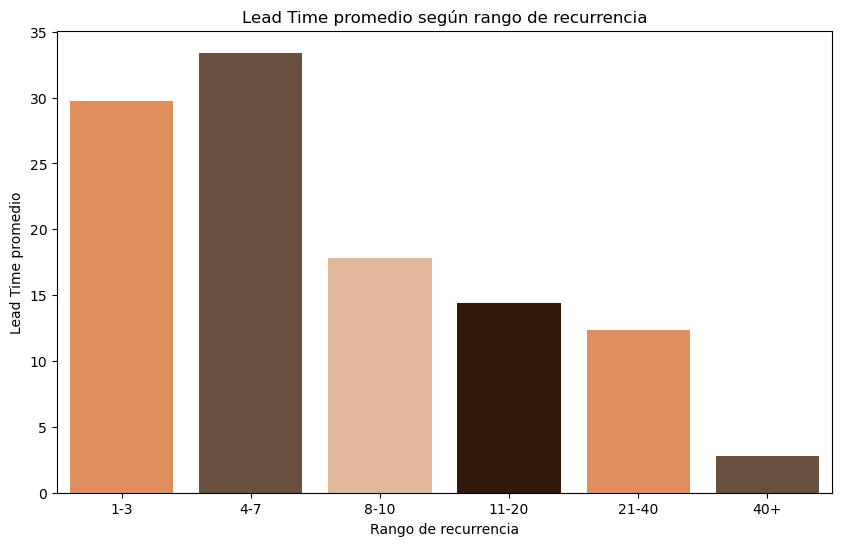

In [62]:
# Definir los rangos incluyendo >40
bins = [0, 3, 7, 10, 20, 40, np.inf]
labels = ['1-3', '4-7', '8-10', '11-20', '21-40', '40+']

# Crear columna con rango
df['recurrence_range'] = pd.cut(df['recurrence'], bins=bins, labels=labels, right=True)

# Agrupar por rango y calcular la media
df_grouped = df.groupby('recurrence_range')['lead_time'].mean().reset_index()

# Paleta personalizada
paleta = ["#F48A48","#6F4E37","#EBB68D","#391704"]

# Graficar
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_grouped,
    x='recurrence_range',
    y='lead_time',
    palette=paleta  # Se repetirá automáticamente para 6 rangos
)
plt.title("Lead Time promedio según rango de recurrencia")
plt.xlabel("Rango de recurrencia")
plt.ylabel("Lead Time promedio")
plt.show()



4º GRAFICO : Mes vs fin de semana

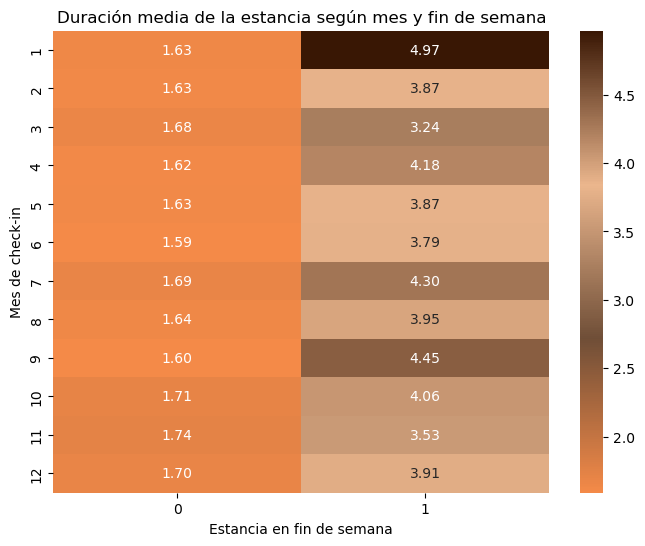

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Pivot table
pivot = df.pivot_table(
    values="lenght_of_stay",
    index="mes_checkin_numerico",
    columns="estancia_en_finde",
    aggfunc="mean"
)

# Crear colormap con tu paleta
custom_cmap = LinearSegmentedColormap.from_list("custom_palette", paleta)

# Graficar heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap
)

plt.title("Duración media de la estancia según mes y fin de semana")
plt.xlabel("Estancia en fin de semana")
plt.ylabel("Mes de check-in")
plt.show()


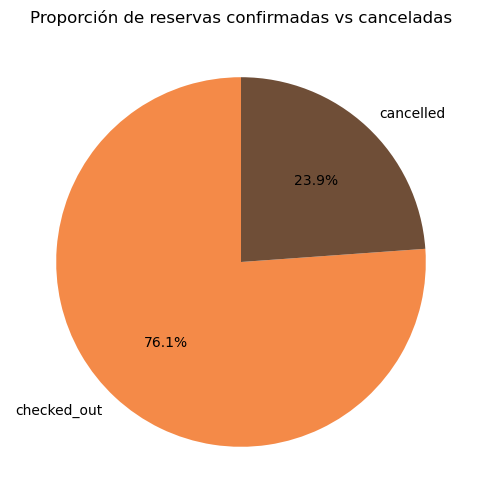

In [73]:
status_counts = df['status'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=list(paleta)
)
plt.title("Proporción de reservas confirmadas vs canceladas")
plt.show()



6º GRAFICO: Reservas por mes y día de la semana

C:\Users\Larau\AppData\Local\Temp\ipykernel_65924\1165047835.py:2: UserWarning: 
The palette list has fewer values (4) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(


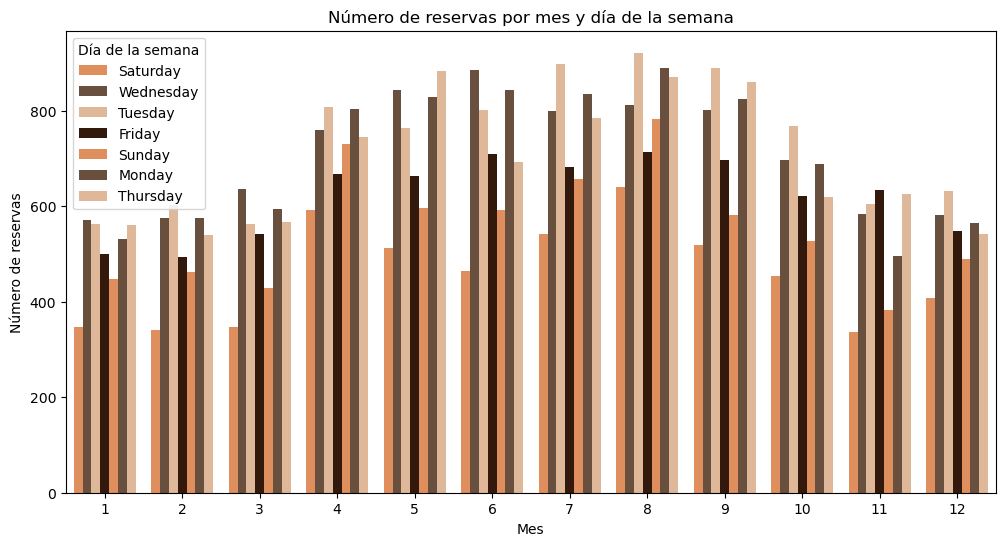

In [74]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x="mes_checkin_numerico",
    hue="Reserva_Dia_Semana",
    palette=paleta
)
plt.title("Número de reservas por mes y día de la semana")
plt.xlabel("Mes")
plt.ylabel("Número de reservas")
plt.legend(title="Día de la semana")
plt.show()


7º GRAFICO: Reservas por temporada + valor medio

In [86]:
print(df["reservation_net_value"])

0         15.92
1        117.78
2        755.65
3        186.37
4         77.02
          ...  
53742     169.6
53743     169.6
53744    647.28
53745    732.73
53746    343.64
Name: reservation_net_value, Length: 53747, dtype: object


C:\Users\Larau\AppData\Local\Temp\ipykernel_65924\2820938656.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


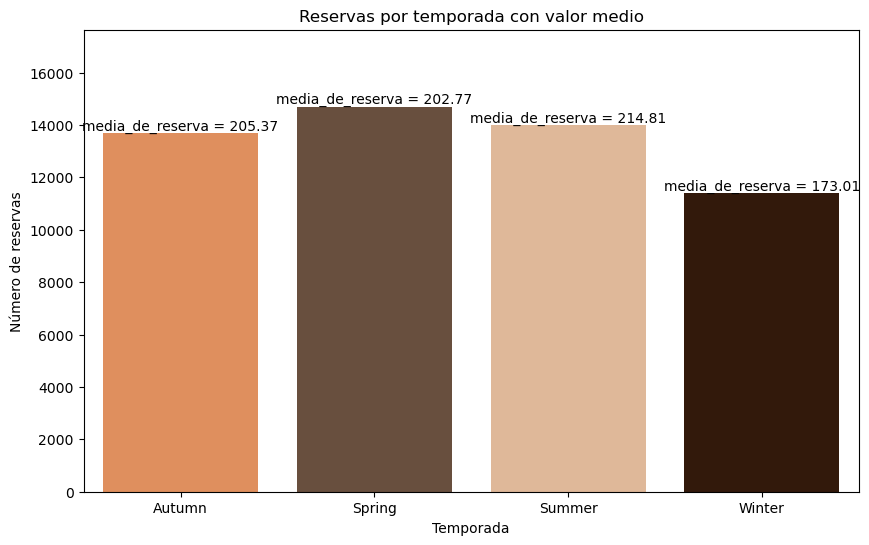

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1️⃣ Convertir la columna a numérico ---
df['reservation_net_value'] = pd.to_numeric(df['reservation_net_value'], errors='coerce')

# --- 2️⃣ Agrupar por temporada ---
season_group = df.groupby('Estacion_Reserva').agg(
    reservas=('status', 'count'),
    valor_medio=('reservation_net_value', 'mean')
).reset_index()

# --- 3️⃣ Definir paleta de colores ---
paleta = ["#F48A48", "#6F4E37", "#EBB68D", "#391704"]
colores = paleta[:len(season_group)]  # asegurarse de que coincida con las categorías

# --- 4️⃣ Graficar barras con etiquetas descriptivas ---
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=season_group,
    x='Estacion_Reserva',
    y='reservas',
    palette=colores
)

# Agregar etiquetas con el valor medio sobre cada barra
for i, row in season_group.iterrows():
    ax.text(
        i,  # posición x de la barra
        row['reservas'] + 1,  # posición y encima de la barra
        f"media_de_reserva = {row['valor_medio']:.2f}",  # etiqueta descriptiva
        ha='center', va='bottom', fontsize=10, color='black'
    )

plt.title("Reservas por temporada con valor medio")
plt.xlabel("Temporada")
plt.ylabel("Número de reservas")
plt.ylim(0, season_group['reservas'].max()*1.20)  # dar espacio para las etiquetas
plt.show()

